# Session 1: Multiple Linear Regression
## Wheat Yield Prediction 
  
**Goal:** Understand our dataset and build your first yield prediction model using Multiple Linear Regression

---

### Activities
|  | Tasks |
|------|-------|
| Part 1 | Loading & first look at the data |
| Part 2 | Exploratory Data Analysis (EDA) |
| Part 3 | Multiple Linear Regression |
| Part 4 | Model evaluation & limitations |
| Part 5 | Wrap-up & questions |

---

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')




---
## Part 1: Dataset

The dataset contains **multiscale features** for wheat growing across Western Australia (WA), spanning 1989–2020.  
Each row represents one **grid cell × one year** combination. Please refer to `README.md` for data description. 

### Question — What is in this dataset?
Before loading, think about:
- What kind of variables do you expect to influence wheat yield?
- Spend some time to understand the variables in the data


In [28]:
# Load the data
DATA_PATH = './data/wheat_features.parquet'  

df = pd.read_parquet(DATA_PATH)
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,lat,lon,year,sowing_doy,wheat_yield,pawc_0_30_mm,ph_0_30,rain_mpre6,rain_mpre5,rain_mpre4,...,fasw_mean_m8,gdd_m8,rain_preseason,rain_early,rain_late,gdd_may_nov,frost_days_aug_oct,heat_days_aug_oct,rad_aug_oct,fasw_mean_aug_oct
0,-35.000000,117.099998,1989,91.0,3.306941,17.0,4.6,0.0,0.0,0.0,...,0.014462,568.000000,80.399170,582.896484,278.095947,2970.650146,0.0,0.0,1422.399902,0.039833
1,-35.000000,117.150002,1989,91.0,3.083793,17.0,4.6,0.0,0.0,0.0,...,0.017400,570.950073,79.499512,580.195068,277.197998,2985.199219,0.0,0.0,1426.900024,0.051236
2,-34.950001,116.949997,1989,91.0,2.841632,17.0,4.6,0.0,0.0,0.0,...,0.017547,566.100037,86.297852,569.896240,271.397461,2961.050293,0.0,0.0,1413.600342,0.051688
3,-34.950001,117.000000,1989,91.0,2.918803,17.0,4.6,0.0,0.0,0.0,...,0.018527,567.199951,81.398193,556.695312,268.096436,2960.500000,0.0,0.0,1417.000122,0.050082
4,-34.950001,117.050003,1989,91.0,2.707774,30.0,4.8,0.0,0.0,0.0,...,0.010101,567.650085,80.899414,562.894531,267.997314,2953.899902,0.0,0.0,1419.599609,0.031298


---
## Part 2: Exploratory Data Analysis (EDA)

Before building any model, we **must** understand the data.  
EDA helps us find: missing values, outliers, distributions, and correlations.

**Let's focus on calendar crop columns (`rain_preseason`, `rain_early`, `rain_late`, `gdd_may_nov`, `frost_days_aug_oct`,
                 `heat_days_aug_oct`,  `rad_aug_oct`,  `faws_aug_oct`), `pawc_0_30`,`ph_0_30`  for now**

### Questions
1. Did you notice anything in the summary statistics of the variables? What should we do?

In [29]:

print('=== Summary statistics for key variables ===')
key_cols = ['wheat_yield'] +  ['pawc_0_30_mm',  'ph_0_30']+ ['sowing_doy','rain_preseason', 'rain_early', 'rain_late', 'gdd_may_nov', 'frost_days_aug_oct',
                 'heat_days_aug_oct','rad_aug_oct', 'fasw_mean_aug_oct']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(3)

=== Summary statistics for key variables ===


,wheat_yield,pawc_0_30_mm,ph_0_30,sowing_doy,rain_preseason,rain_early,rain_late,gdd_may_nov,frost_days_aug_oct,heat_days_aug_oct,rad_aug_oct,fasw_mean_aug_oct
count,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000
mean,1.798,28.462,5.032,131.718,51.594,203.196,76.232,3094.903,4.888,2.548,1640.165,0.022
std,1.046,4.933,0.588,32.543,39.766,81.830,44.758,290.049,5.554,2.763,135.543,0.008
min,0.000,17.000,4.600,91.000,0.000,22.799,0.000,2408.950,0.000,0.000,1206.200,0.004
25%,0.970,30.000,4.800,103.000,22.099,147.597,44.698,2870.987,0.000,0.000,1538.000,0.016
50%,1.673,30.000,4.800,127.000,42.099,187.898,69.799,3055.649,3.000,2.000,1639.600,0.021
75%,2.526,30.000,4.800,147.000,70.398,240.197,99.299,3287.450,8.000,4.000,1743.100,0.027
max,6.938,58.105,8.233,213.000,308.499,1091.396,452.596,4137.900,33.000,20.000,2030.200,0.111


In [30]:
# Missing data
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} / {len(df.columns)}')


Columns with missing values: 0 / 57


Rows with wheat_yield == 0 : 148
Unique grid cells affected : 103


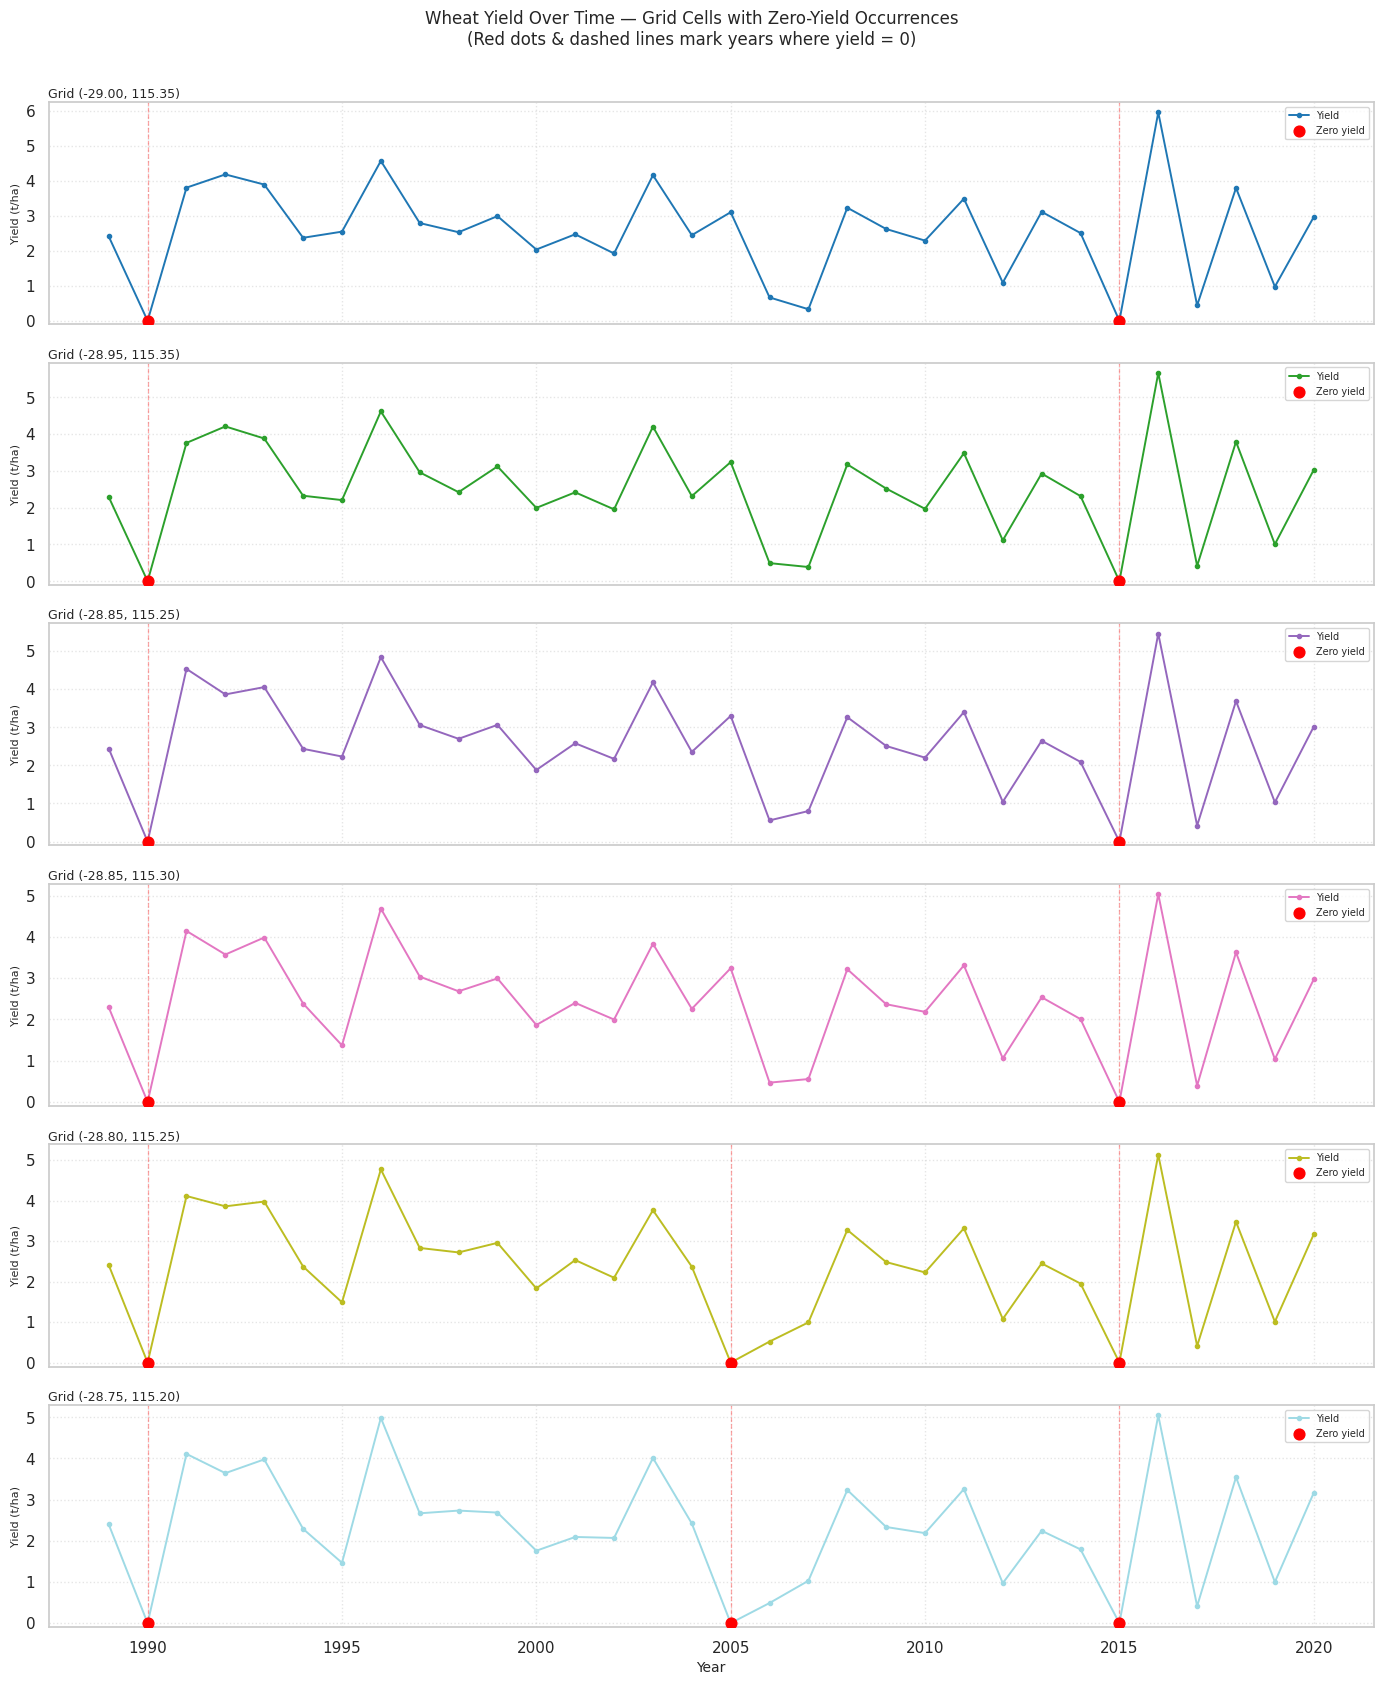

Figure saved → zero_yield_grids_over_time.png

Top grid cells by number of zero-yield years:
       lat        lon  n_zero_years               zero_years
-30.400000 115.849998             4 [1998, 2000, 2007, 2015]
-29.100000 115.000000             3       [2000, 2015, 2017]
-29.150000 115.050003             3       [2000, 2015, 2017]
-29.150000 114.949997             3       [1999, 2000, 2015]
-28.850000 115.199997             3       [2005, 2015, 2017]
-28.750000 115.199997             3       [1990, 2005, 2015]
-28.799999 115.250000             3       [1990, 2005, 2015]
-28.700001 115.250000             3       [1990, 2005, 2015]
-28.750000 115.250000             3       [1990, 2005, 2015]
-29.299999 115.050003             2             [2007, 2017]
-28.850000 115.300003             2             [1990, 2015]
-28.850000 115.250000             2             [1990, 2015]
-29.100000 114.900002             2             [2000, 2015]
-29.650000 115.250000             2             [2010

In [31]:
"""
Plot wheat_yield == 0 for affected grid cells over time.

"""
zero_mask   = df['wheat_yield'] == 0
zero_grids  = df.loc[zero_mask, ['lat', 'lon']].drop_duplicates()

print(f"Rows with wheat_yield == 0 : {zero_mask.sum()}")
print(f"Unique grid cells affected : {len(zero_grids)}")

# Select up to 6 grids for readability 
MAX_GRIDS = 6
sample_grids = zero_grids.head(MAX_GRIDS)

# Build a time-series for each sampled grid 
records = []
for _, row in sample_grids.iterrows():
    mask = (df['lat'] == row['lat']) & (df['lon'] == row['lon'])
    ts   = df.loc[mask, ['year', 'wheat_yield']].sort_values('year')
    ts['grid'] = f"({row['lat']:.2f}, {row['lon']:.2f})"
    records.append(ts)

ts_df = pd.concat(records, ignore_index=True)

#  Plot 
n_grids = ts_df['grid'].nunique()
colors  = cm.tab20(np.linspace(0, 1, n_grids))

fig, axes = plt.subplots(
    n_grids, 1,
    figsize=(14, 2.8 * n_grids),
    sharex=True
)

if n_grids == 1:
    axes = [axes]

for ax, (grid_id, color) in zip(axes, zip(ts_df['grid'].unique(), colors)):
    sub = ts_df[ts_df['grid'] == grid_id]

    # Full time-series line
    ax.plot(sub['year'], sub['wheat_yield'],
            color=color, linewidth=1.4, marker='o', markersize=3, label='Yield')

    # Highlight zero-yield years
    zeros = sub[sub['wheat_yield'] == 0]
    ax.scatter(zeros['year'], zeros['wheat_yield'],
               color='red', zorder=5, s=60, label='Zero yield')
    for yr in zeros['year']:
        ax.axvline(x=yr, color='red', linestyle='--', alpha=0.35, linewidth=0.9)

    ax.set_ylabel('Yield (t/ha)', fontsize=8)
    ax.set_title(f'Grid {grid_id}', fontsize=9, loc='left', pad=3)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylim(bottom=-0.1)

axes[-1].set_xlabel('Year', fontsize=10)
fig.suptitle(
    f'Wheat Yield Over Time — Grid Cells with Zero-Yield Occurrences\n'
    f'(Red dots & dashed lines mark years where yield = 0)',
    fontsize=12, y=1.002
)
plt.tight_layout()
plt.show()
print("Figure saved → zero_yield_grids_over_time.png")

# Summary table 
summary = (
    df[df['wheat_yield'] == 0]
    .groupby(['lat', 'lon'])['year']
    .agg(n_zero_years='count', zero_years=list)
    .reset_index()
    .sort_values('n_zero_years', ascending=False)
)
print("\nTop grid cells by number of zero-yield years:")
print(summary.head(20).to_string(index=False))

In [32]:
# Flag suspect

suspect = (df['wheat_yield'] < 0.01) & (df['sowing_doy'] > 0)
print(f"Suspect zero-yield rows (sown but yield=0): {suspect.sum()}")
 
#  Window-median replacement
WINDOW = 3   # years on each side
 
def replace_zeros_window_median(series: pd.Series,
                                 suspect_mask: pd.Series,
                                 window: int = WINDOW) -> pd.Series:
    """
    For each flagged position, compute the median of up to `window`
    valid (non-zero, non-NaN) neighbours on each side in the time series.
    Falls back to the cell-wide positive median if fewer than 2 neighbours exist.
    """
    s = series.copy().astype(float)
    fallback_median = s[s > 0].median()
 
    for idx in s.index[suspect_mask.reindex(s.index, fill_value=False)]:
        pos = s.index.get_loc(idx)
 
        # Gather up to `window` values on each side, skipping zeros/NaN
        left  = [v for v in s.iloc[max(0, pos - window): pos]        if v > 0]
        right = [v for v in s.iloc[pos + 1: pos + 1 + window]        if v > 0]
        neighbours = left + right
 
        if len(neighbours) >= 2:
            s.iloc[pos] = np.median(neighbours)
        else:
            # Edge case: not enough neighbours → use cell-wide median
            s.iloc[pos] = fallback_median
 
    return s
 
 
df['wheat_yield'] = (
    df.groupby(['lat', 'lon'], group_keys=False)
    .apply(lambda g: replace_zeros_window_median(
        g['wheat_yield'],
        suspect.loc[g.index]
    ))
)

Suspect zero-yield rows (sown but yield=0): 464


In [33]:
#  Verify no zeros remain (for sown rows) 
remaining = ((df['wheat_yield'] == 0) & (df['sowing_doy'] >0)).sum()
print(f"Remaining suspect zeros after replacement: {remaining}")
print(f"New yield stats:\n{df['wheat_yield'].describe().round(3)}")
 

Remaining suspect zeros after replacement: 0
New yield stats:
count    227584.000
mean          1.801
std           1.043
min           0.010
25%           0.974
50%           1.676
75%           2.527
max           6.938
Name: wheat_yield, dtype: float64


In [9]:
# Check what's behind the remaining zeros
remaining_zeros = df[df['wheat_yield'] == 0]
print(f"Total remaining zeros: {len(remaining_zeros)}")



Total remaining zeros: 0


### Question — Interpreting the Yield Distribution
1. Is the yield distribution symmetric (normal) or skewed?
2. Do you notice any trend over time? What might cause it?
3. Are there years with unusually low yield? What events might explain this?

In [10]:
# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

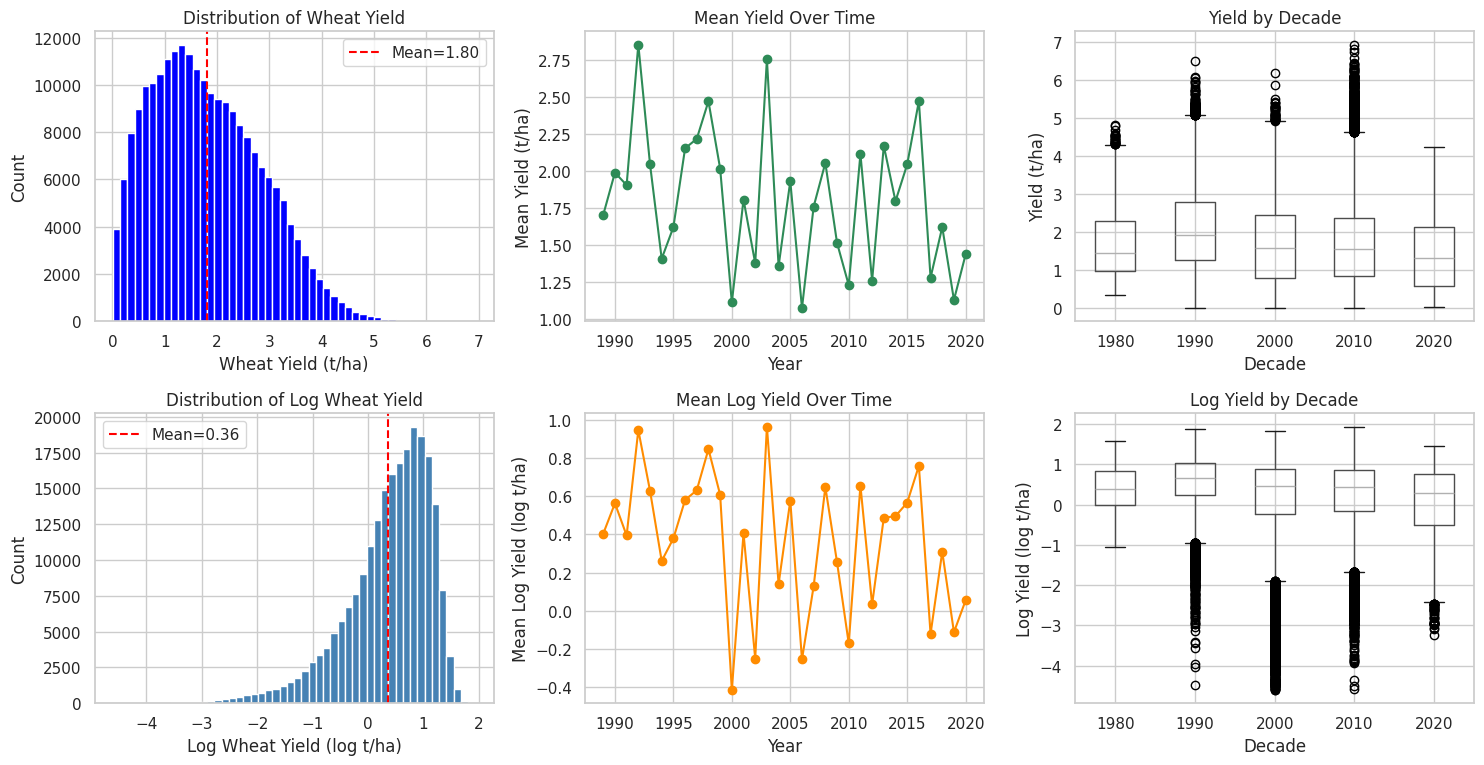

Yield stats:     mean=1.80, std=1.04, min=0.01, max=6.94 t/ha
Log yield stats: mean=0.36, std=0.79, min=-4.60, max=1.94 log t/ha


In [11]:
# Create log yield column 
df = df[df['wheat_yield'] > 0].copy()
df['log_wheat_yield'] = np.log(df['wheat_yield'])

# Wheat yield distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))



# Histogram
axes[0, 0].hist(df['wheat_yield'], bins=50, color='blue', edgecolor='white')
axes[0, 0].set_xlabel('Wheat Yield (t/ha)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Wheat Yield')
axes[0, 0].axvline(df['wheat_yield'].mean(), color='red', linestyle='--',
                   label=f"Mean={df['wheat_yield'].mean():.2f}")
axes[0, 0].legend()

# Yield by year
yr_mean = df.groupby('year')['wheat_yield'].mean()
axes[0, 1].plot(yr_mean.index, yr_mean.values, marker='o', color='seagreen')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Mean Yield (t/ha)')
axes[0, 1].set_title('Mean Yield Over Time')

# Boxplot by decade
df['decade'] = (df['year'] // 10) * 10
df.boxplot(column='wheat_yield', by='decade', ax=axes[0, 2])
axes[0, 2].set_xlabel('Decade')
axes[0, 2].set_ylabel('Yield (t/ha)')
axes[0, 2].set_title('Yield by Decade')


df['log_wheat_yield'] = np.log(df['wheat_yield'])

# Histogram
axes[1, 0].hist(df['log_wheat_yield'], bins=50, color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel('Log Wheat Yield (log t/ha)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Log Wheat Yield')
axes[1, 0].axvline(df['log_wheat_yield'].mean(), color='red', linestyle='--',
                   label=f"Mean={df['log_wheat_yield'].mean():.2f}")
axes[1, 0].legend()

# Log yield by year
yr_mean_log = df.groupby('year')['log_wheat_yield'].mean()
axes[1, 1].plot(yr_mean_log.index, yr_mean_log.values, marker='o', color='darkorange')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Mean Log Yield (log t/ha)')
axes[1, 1].set_title('Mean Log Yield Over Time')

# Boxplot log yield by decade
df.boxplot(column='log_wheat_yield', by='decade', ax=axes[1, 2])
axes[1, 2].set_xlabel('Decade')
axes[1, 2].set_ylabel('Log Yield (log t/ha)')
axes[1, 2].set_title('Log Yield by Decade')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Yield stats:     mean={df['wheat_yield'].mean():.2f}, "
      f"std={df['wheat_yield'].std():.2f}, "
      f"min={df['wheat_yield'].min():.2f}, "
      f"max={df['wheat_yield'].max():.2f} t/ha")
print(f"Log yield stats: mean={df['log_wheat_yield'].mean():.2f}, "
      f"std={df['log_wheat_yield'].std():.2f}, "
      f"min={df['log_wheat_yield'].min():.2f}, "
      f"max={df['log_wheat_yield'].max():.2f} log t/ha")

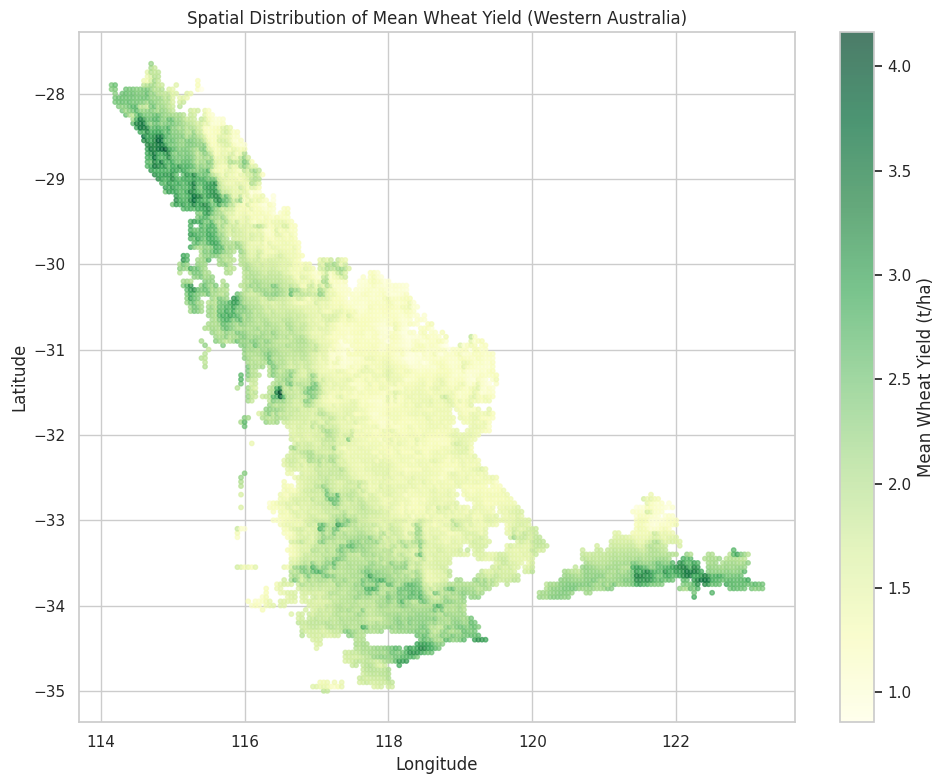

In [12]:
#  Spatial distribution of yield 
yield_by_cell = df.groupby(['lat', 'lon'])['wheat_yield'].mean().reset_index()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    yield_by_cell['lon'], yield_by_cell['lat'],
    c=yield_by_cell['wheat_yield'],
    cmap='YlGn', s=10, alpha=0.7
)
plt.colorbar(scatter, label='Mean Wheat Yield (t/ha)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Mean Wheat Yield (Western Australia)')
plt.tight_layout()
plt.show()

### Question — Feature Relationships
1. Which weather variable has the strongest positive correlation with yield? Does this make sense?
2. Which soil variable, if any, shows a relationship with yield?

In [41]:
corr_features = (
    ['pawc_0_30_mm',  'ph_0_30'] +
    ['rain_preseason', 'rain_early', 'rain_late',
     'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct',
    'rad_aug_oct', 'fasw_mean_aug_oct']+
    ['wheat_yield']
)

corr_matrix = df[corr_features].corr()
yield_corr = corr_matrix['wheat_yield'].drop('wheat_yield').sort_values(key=abs, ascending=False)

print('Top features correlated with wheat_yield:')
print(yield_corr.head(15).round(3))

Top features correlated with wheat_yield:
rain_early            0.319
rain_late             0.268
frost_days_aug_oct   -0.241
heat_days_aug_oct    -0.233
fasw_mean_aug_oct     0.225
rad_aug_oct          -0.172
ph_0_30               0.130
pawc_0_30_mm         -0.104
rain_preseason        0.072
gdd_may_nov          -0.016
Name: wheat_yield, dtype: float64


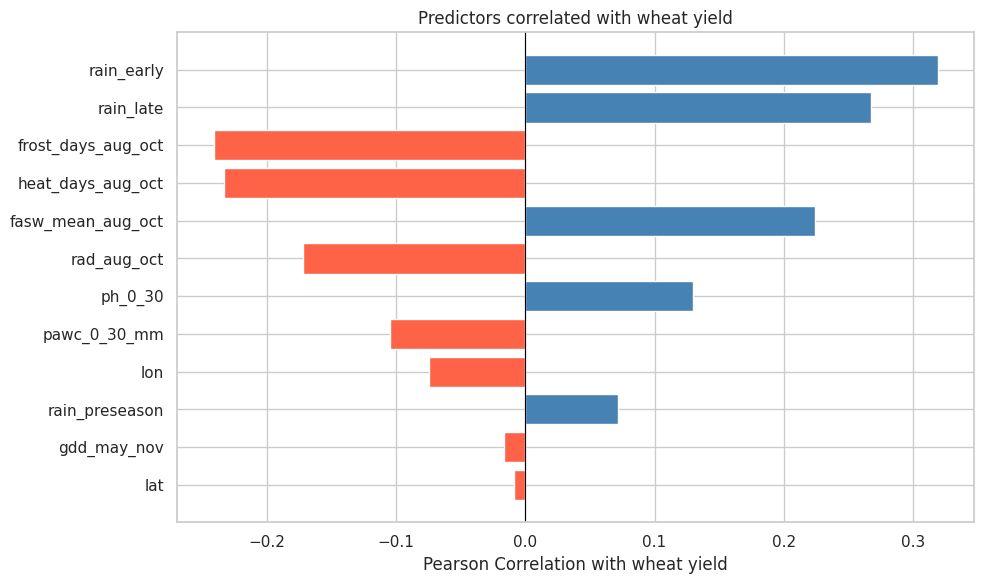

In [40]:
# Visualise correlations 
fig, ax = plt.subplots(figsize=(10, 6))
top15 = yield_corr.head(15)
colors = ['steelblue' if v > 0 else 'tomato' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with wheat yield')
ax.set_title('Predictors correlated with wheat yield')
plt.tight_layout()
plt.show()

---
## Part 3: Multiple Linear Regression

**Linear regression** assumes that yield is a weighted sum of input features:  

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_n x_n$$

Where:
- $\hat{y}$ = predicted yield
- $x_i$ = input features (rain, temperature, soil, etc.)
- $b_i$ = coefficients 
- $b_0$ = intercept 

The model **learns** the best weights by minimising the sum of squared errors

### Question - Model
1. Before running a model, is there anything we need to do with the data?
2. Shall we run the model on `wheat_yield` or `log_wheat_yield`


In [46]:

# Apply rescaling
df_model = df.copy()

df_model['gdd_may_nov']      = df_model['gdd_may_nov']      / 1000   # per 1000 GDD
df_model['rain_early']       = df_model['rain_early']       / 100    # per 100 mm
df_model['rain_late']        = df_model['rain_late']        / 100    # per 100 mm
df_model['rain_preseason']   = df_model['rain_preseason']   / 100    # per 100 mm
df_model['rain_mpre3']   = df_model['rain_mpre3']   / 100    # per 100 mm
df_model['rain_mpre2']   = df_model['rain_mpre2']   / 100    # per 100 mm
df_model['pawc_0_30_mm']   = df_model['pawc_0_30_mm']   / 100    # per 100 mm
df_model['rad_aug_oct']   = df_model['rad_aug_oct']   / 1000    # 
# df_model['rain_sum_mpre1']   = df_model['rain_sum_mpre1']   / 100    # per 100 mm
df_model['log_wheat_yield'] = np.log(df_model['wheat_yield'])

FEATURE_COLS = [
    'pawc_0_30_mm', 'ph_0_30',
    'rain_preseason', 'rain_early', 'rain_late',
    'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct',
    'rad_aug_oct', 'fasw_mean_aug_oct']

df_model[key_cols].describe().round(3)


,wheat_yield,pawc_0_30_mm,ph_0_30,sowing_doy,rain_preseason,rain_early,rain_late,gdd_may_nov,frost_days_aug_oct,heat_days_aug_oct,rad_aug_oct,fasw_mean_aug_oct
count,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000,227584.000
mean,1.801,0.285,5.032,131.718,0.516,2.032,0.762,3.095,4.888,2.548,1.640,0.022
std,1.043,0.049,0.588,32.543,0.398,0.818,0.448,0.290,5.554,2.763,0.136,0.008
min,0.010,0.170,4.600,91.000,0.000,0.228,0.000,2.409,0.000,0.000,1.206,0.004
25%,0.974,0.300,4.800,103.000,0.221,1.476,0.447,2.871,0.000,0.000,1.538,0.016
50%,1.676,0.300,4.800,127.000,0.421,1.879,0.698,3.056,3.000,2.000,1.640,0.021
75%,2.527,0.300,4.800,147.000,0.704,2.402,0.993,3.287,8.000,4.000,1.743,0.027
max,6.938,0.581,8.233,213.000,3.085,10.914,4.526,4.138,33.000,20.000,2.030,0.111


In [43]:
X = df_model[FEATURE_COLS]
y = df_model['log_wheat_yield']

X_with_const = sm.add_constant(df_model[FEATURE_COLS])
model = sm.OLS(df_model['log_wheat_yield'], X_with_const).fit()

print(model.summary())


print(model.params)      
print(model.rsquared)

                            OLS Regression Results                            
Dep. Variable:        log_wheat_yield   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     6034.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:55:29   Log-Likelihood:            -2.3690e+05
No. Observations:              227584   AIC:                         4.738e+05
Df Residuals:                  227571   BIC:                         4.740e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  7.4922      0

### Question — Interpreting Coefficients
1. Which features have the largest (absolute) coefficient? Are they what you expected?
2. A **positive** coefficient means: as the feature increases, yield ___?
3. A **negative** coefficient means: as the feature increases, yield ___?
4. Does the sign of each coefficient make agronomic sense?

---
## Evaluation the model performane
### Question: Training strategy
- what training design we could implement here?

In [44]:



FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET_COL = 'log_wheat_yield'

train = df_model[df_model['year'] <= 2018]
test  = df_model[df_model['year'] >= 2019]

X_train = sm.add_constant(train[FEATURE_COLS])
X_test  = sm.add_constant(test[FEATURE_COLS])
y_train = train[TARGET_COL]
y_test  = test[TARGET_COL]

print(f'Train: {train.year.min()}–{train.year.max()}  ({len(train):,} rows)')
print(f'Test : {test.year.min()}–{test.year.max()}   ({len(test):,} rows)')

Train: 1989–2018  (213,360 rows)
Test : 2019–2020   (14,224 rows)


---
## Part 4: Model Evaluation

We use three main metrics to evaluate regression models:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(\hat{y}-y)^2}$ | Average error in same units as yield (t/ha) — penalises large errors more heavily |
| **MAE** | $\frac{1}{n}\sum|\hat{y}-y|$ | Average absolute error — less sensitive to outliers than RMSE |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of variance explained (1.0 = perfect, 0 = no better than mean) |
| **LCCC** | $\frac{2\rho\sigma_a\sigma_p}{\sigma_a^2 + \sigma_p^2 + (\mu_a - \mu_p)^2}$ | Agreement between predicted and actual on the 1:1 line (1.0 = perfect, 0 = no agreement) |

where $\rho$ is the Pearson correlation, $\sigma$ the standard deviation, and $\mu$ the mean of actual ($a$) and predicted ($p$) values.

**Why LCCC alongside R²?**  
R² only measures *precision* — how tightly predictions correlate with observations — but does not penalise systematic bias. LCCC measures *concordance*: it penalises both poor correlation **and** deviation from the 1:1 line. It decomposes as:

$$\text{LCCC} = r \times C_b$$

| Component | Meaning |
|---|---|
| $r$ | Pearson correlation — precision (are predictions ranking sites correctly?) |
| $C_b = \frac{2\sigma_a\sigma_p}{\sigma_a^2 + \sigma_p^2 + (\mu_a-\mu_p)^2}$ | Bias correction factor — accuracy (how close to the 1:1 line?) |

A model with high $r$ but low $C_b$ ranks sites correctly but is systematically biased in absolute yield — a common pattern in this dataset given the persistent under-prediction bias of ~−0.2 t/ha.

In [45]:
# Fit on training data only 
ols_model = sm.OLS(y_train, X_train).fit()

log_pred_test  = ols_model.predict(X_test)
pred_test_tha  = np.exp(log_pred_test)
actual_test    = test['wheat_yield'].values

# Metrics 
def concordance_cc(actual, predicted):
    """Lin's Concordance Correlation Coefficient"""
    mean_act  = np.mean(actual)
    mean_pred = np.mean(predicted)
    var_act   = np.var(actual)
    var_pred  = np.var(predicted)
    covariance = np.mean((actual - mean_act) * (predicted - mean_pred))
    
    lccc = (2 * covariance) / (var_act + var_pred + (mean_act - mean_pred)**2)
    return lccc

def eval_metrics(actual, predicted, label):
    r2   = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    bias = np.mean(predicted - actual)
    lccc = concordance_cc(actual, predicted)        # ← added

    print(f'{label}')
    print(f'  R²   = {r2:.3f}')
    print(f'  LCCC = {lccc:.3f}')                  # ← added
    print(f'  RMSE = {rmse:.3f} t/ha')
    print(f'  MAE  = {mae:.3f} t/ha')
    print(f'  Bias = {bias:+.3f} t/ha  ({"over" if bias > 0 else "under"}-predicting)')
    print()
    return r2, rmse, mae, bias, lccc

print('='*45)
r2_te, rmse_te, mae_te, bias_te, lccc_te = eval_metrics(actual_test,  pred_test_tha,  'TEST  ')

TEST  
  R²   = 0.257
  LCCC = 0.371
  RMSE = 0.760 t/ha
  MAE  = 0.599 t/ha
  Bias = -0.109 t/ha  (under-predicting)



In [23]:
def lccc_components(actual,predicted, label):
    """Break LCCC into precision (r) and accuracy (Cb) components"""
    r, _      = stats.pearsonr(actual, predicted)   
    mean_act  = np.mean(actual)
    mean_pred = np.mean(predicted)
    var_act   = np.var(actual)
    var_pred  = np.var(predicted)
    
    std_act   = np.std(actual)
    std_pred  = np.std(predicted)
    
    # Bias correction factor Cb — how far the best-fit line deviates from 1:1
    Cb = (2 * std_act * std_pred) / (var_act + var_pred + (mean_act - mean_pred)**2)
    lccc = r * Cb
    
    print(f'{label}')
    print(f'  LCCC = {lccc:.3f}  (r={r:.3f} × Cb={Cb:.3f})')
    print(f'  r  = {r:.3f}  → precision  (how correlated are predictions and observations)')
    print(f'  Cb = {Cb:.3f}  → accuracy   (how close to the 1:1 line, penalises bias & scale)')
    print()

lccc_components(actual_test,  pred_test_tha,  'TEST ')

TEST 
  LCCC = 0.563  (r=0.674 × Cb=0.835)
  r  = 0.674  → precision  (how correlated are predictions and observations)
  Cb = 0.835  → accuracy   (how close to the 1:1 line, penalises bias & scale)



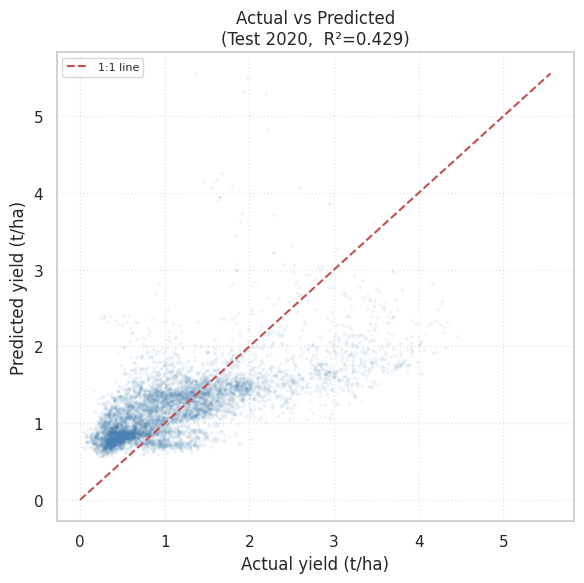

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(actual_test, pred_test_tha, alpha=0.05, s=3, color='steelblue')
lims = [0, max(actual_test.max(), pred_test_tha.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='1:1 line')
ax.set_xlabel('Actual yield (t/ha)')
ax.set_ylabel('Predicted yield (t/ha)')
ax.set_title(f'Actual vs Predicted\n(Test 2020,  R²={r2_te:.3f})')
ax.legend(fontsize=8)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


---
### Question — Residual Interpretation
A well-fitted linear regression should have residuals that:
1. Are centred around zero (no systematic bias)
2. Show no pattern when plotted against predicted values
3. Follow an approximately normal distribution

Look at the residual plots above:
- Do residuals show a **funnel shape** (wider at high/low yields)? What does this indicate?
- Are there clusters of large errors? When might this happen?

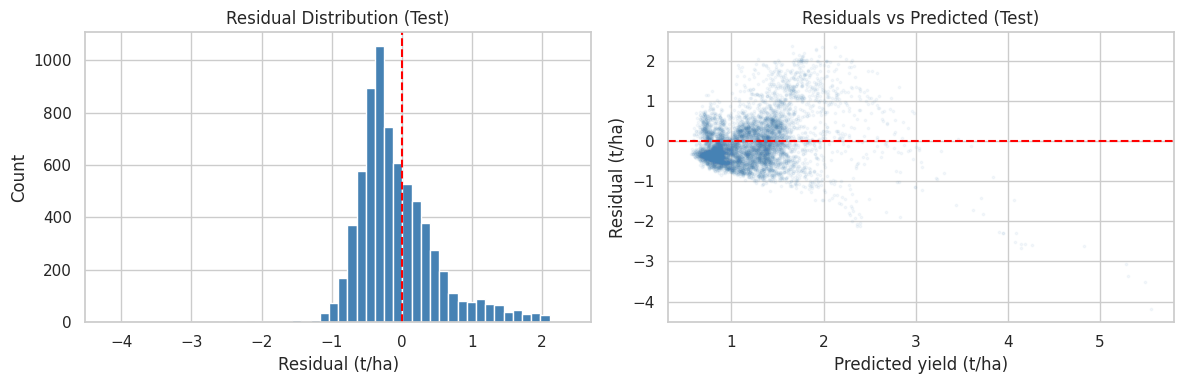

In [123]:
residuals_test = actual_test - pred_test_tha

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of residuals
axes[0].hist(residuals_test, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (t/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution (Test)')

# Residuals vs predicted — checks for heteroscedasticity
axes[1].scatter(pred_test_tha, residuals_test, alpha=0.05, s=3, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted yield (t/ha)')
axes[1].set_ylabel('Residual (t/ha)')
axes[1].set_title('Residuals vs Predicted (Test)')

plt.tight_layout()
plt.show()

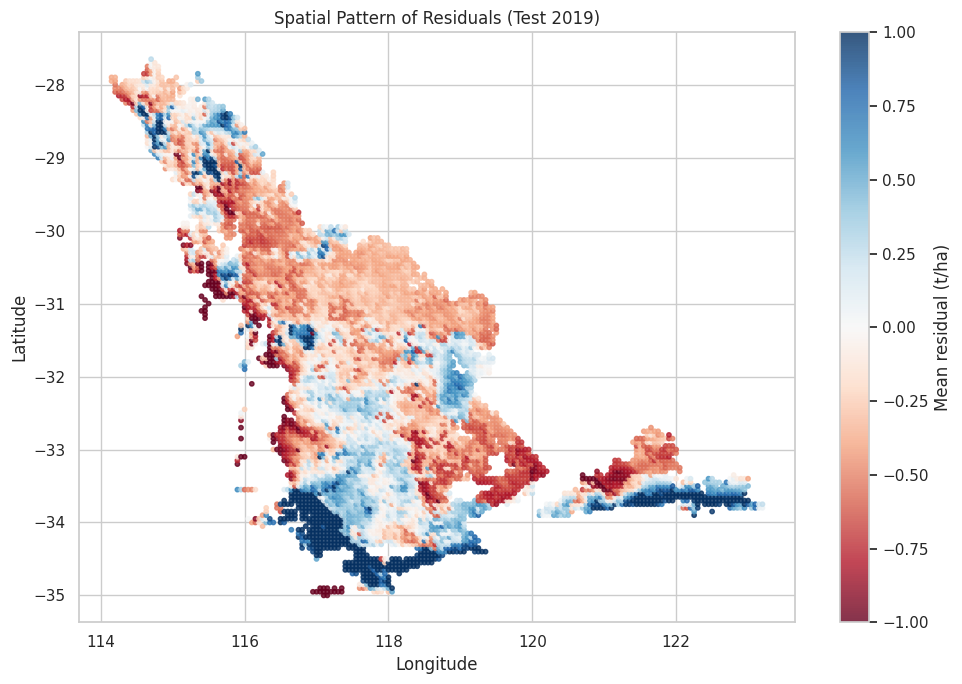

In [126]:
test_copy = test.copy()
test_copy['residual'] = actual_test - pred_test_tha

# Mean residual per grid cell
spatial = test_copy.groupby(['lat', 'lon'])['residual'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(spatial['lon'], spatial['lat'],
                c=spatial['residual'], cmap='RdBu',
                vmin=-1, vmax=1, s=10, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Mean residual (t/ha)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Pattern of Residuals (Test 2019)')
plt.tight_layout()
plt.show()

---
## Part 4 (cont.): Limitations of Linear Regression

### When Does Linear Regression Fail?

Consider these **limitations** and check whether they apply to our data:

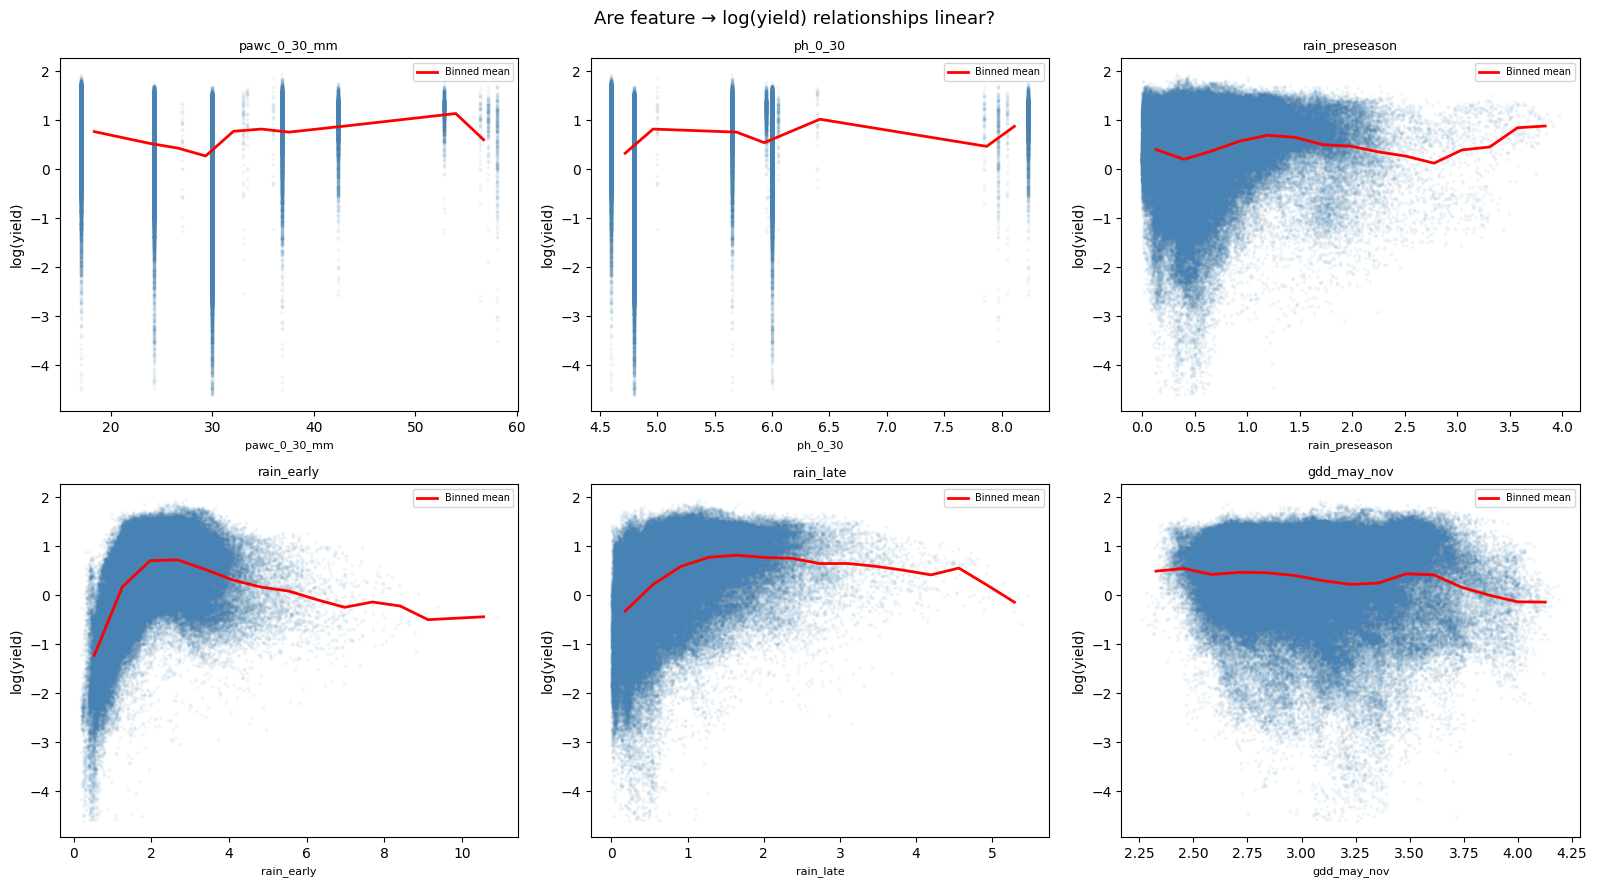

If the red line curves or flattens, the relationship is non-linear.
Linear regression will miss this — even after log-transforming yield.


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.flat, FEATURE_COLS):
    ax.scatter(df_model[feat], df_model['log_wheat_yield'], alpha=0.05, s=3, color='steelblue')

    # Overlay binned mean — drop empty bins to keep xs and ys aligned
    bins    = pd.cut(df_model[feat], bins=15)
    grp     = df_model.groupby(bins, observed=True)['log_wheat_yield']  # observed=True drops empty bins
    xs      = [b.mid for b in grp.mean().index]                         # index, not .categories
    ys      = grp.mean().values

    ax.plot(xs, ys, color='red', linewidth=2, label='Binned mean')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('log(yield)')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Are feature → log(yield) relationships linear?', fontsize=13)
plt.tight_layout()
plt.show()

print('If the red line curves or flattens, the relationship is non-linear.')
print('Linear regression will miss this — even after log-transforming yield.')

---
##  Homework

**Exercise A:** Add more features from the monthly calendar columns to the model. Does R² improve? Does the model performance improve?

**Exercise B:** Consider using the variables based on monthly frequency. Try Ridge Regression (`from sklearn.linear_model import Ridge`) instead of linear regression. Ridge adds a penalty to prevent large coefficients. Does it perform differently? Why might it help?

---
